# Diet intake and the lipid profile in CVD — data feasibility check

**Research question.** How does diet intake influence the lipid profile of CVD? *(Lipid profile, Diet)*

This notebook answers the six feasibility questions:

1. Can the research question be answered with the data?
2. Do the variables exist? What are the response variable(s), and their class proportions / numeric summary?
3. What are the main predictor variables of interest?
4. What are the potential confounding variables?
5. How many samples remain once every required variable is present?
6. A few simple analyses to see whether the question can be answered, with the initial results visualised.

### Answers at a glance

| | |
|---|---|
| **Survey** | National Nutrition & Physical Activity Survey 2011–12 (`NPA 11-12/`) — the only AHS component with quantitative dietary intake |
| **Response** | five banded lipid biomarkers + dyslipidaemia status (`CVDMEDST`) |
| **Main predictors** | 24-hour recall nutrients, ADG food-group serves, discretionary-energy share |
| **Complete-case n** | **3,584** (ApoB, no fasting needed) / 2,956 (fasting LDL & triglycerides) |
| **Answerable?** | Yes — every variable exists and n is adequate. But the diet signal is very weak: see the verdict. |

The National Health Survey (`NHS 11-12/`) is **not** used. It carries no quantitative dietary intake,
and its respondents (`NHS11B…`) are an independent sample from NNPAS (`NPA11B…`), so the two cannot be
merged to borrow variables from each other.

In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# --- Plot theme: recessive grid and axes, thin marks, text in ink not series colour ---
INK, INK2, INK3 = "#0b0b0b", "#52514e", "#8a8880"
SURFACE = "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#dedcd5", "axes.linewidth": 0.8, "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "600",
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "grid.color": "#ebe9e2", "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 8.5, "legend.labelcolor": INK2,
    "font.size": 9.5, "figure.dpi": 120,
})

# Validated categorical slots (first three are all-pairs CVD-safe) + sequential/diverging ramps
CAT = ["#2a78d6", "#eb6834", "#1baf7a"]
SEQ_BLUE = ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5", "#2a78d6", "#256abf",
            "#1c5cab", "#184f95", "#104281"]          # ordinal: no lighter than step 250
DIVERGING = mpl.colors.LinearSegmentedColormap.from_list(
    "blue_gray_red", ["#184f95", "#3987e5", "#9ec5f4", "#f0efec", "#f3a2a1", "#e34948", "#a82826"])

def ordinal_ramp(k):
    """k evenly spaced steps from the ordinal-safe part of the blue ramp."""
    idx = np.linspace(0, len(SEQ_BLUE) - 1, k).round().astype(int)
    return [SEQ_BLUE[i] for i in idx]

DATA = ""   # notebook sits in the project root; folder names are used as-is

---
## 1. Can the question be answered? Loading the files that carry the variables

The Australian Health Survey Basic CURFs split each survey across levels. Three NNPAS files are needed:

| File | Level | Records | Carries |
|---|---|---|---|
| `NPA 11-12/AHSnpa11bp.csv` | person | 12,153 | dietary intake, demographics, condition flags |
| `NPA 11-12/AHSnpa11bb.csv` | biomedical | 12,153 | **the lipid profile** |
| `NPA 11-12/AHSnpa11bf.csv` | food | 341,897 | discretionary-food flag (ultra-processed proxy) |

> **Data-dictionary erratum.** `dictionary/_all.File.variables.xlsx` lists the NNPAS lipid variables
> under `AHSnpa11ba`. That file is the ADG food-group level and has only 11 columns. The biomedical
> file is **`AHSnpa11bb.csv`** (12,153 × 108). The code below uses the correct file.

In [2]:
# ---------------------------------------------------------------- load
PERSON = ["ABSHID","ABSPID","AGEC","SEX","SMKSTAT","BMISC","NPAFINWT","EXLWTBC","SF2SA1QN","INCDEC",
          "SATPER1","SATPER2","TRANPER1","FIBRET1","FIBRET2","SODIUMT1","SODIUMT2","CHOLT1","CHOLT2",
          "ENERGYT1","ENERGYT2","ALCPER1","SUGART1",
          "VEGLEG1N","FRUIT1N","DAIRY1N","DAIRHF1N","DAIRMF1N","DAIRLF1N","MEAT1N","MEATL1N",
          "FISH1N","NUTS1N","UNSAT1N","WHOLGR1N","REFGRA1N",
          "DIETQ5","DIETQ8","DIETQ12","DIETQ14","DIETRDI",
          "HCHOLBC","HYPBC","ISCHBC","HFOBC","CEREVBC","ANGBC","DIABBC"]
BIO    = ["ABSHID","ABSPID","CHOLRESB","LDLRESB","HDLCHREB","TRIGRESB","APOBRESB",
          "CHOLNTR","LDLNTR","HDLCHSEX","TRIGNTR","APOBNTR","CVDMEDST","FASTSTAD"]

person = pd.read_csv(DATA + "NPA 11-12/AHSnpa11bp.csv", usecols=PERSON, low_memory=False)
bio    = pd.read_csv(DATA + "NPA 11-12/AHSnpa11bb.csv", usecols=BIO)
npa    = person.merge(bio, on=["ABSHID", "ABSPID"], validate="1:1")

print(f"person level      : {person.shape}")
print(f"biomedical level  : {bio.shape}")
print(f"merged 1:1 on ABSHID + ABSPID : {npa.shape}")

person level      : (12153, 48)
biomedical level  : (12153, 14)
merged 1:1 on ABSHID + ABSPID : (12153, 60)


### Recoding ABS missing codes

Every banded biomarker uses **97/98** (or **7/8** on the shorter HDL scale) for *not applicable* /
*not reported*. These are ordinary integers in the CSV, so any mean or correlation taken before
recoding is silently wrong. The block below maps them to `NaN`.

Bands are also converted to **band midpoints** so the ordered outcome can be summarised numerically.
That is an approximation, used only for description and rank-based tests — never presented as a
measured concentration.

In [3]:
# ---------------------------------------------------------- recode + derive
VALID_BAND = {"CHOLRESB": range(1, 9), "HDLCHREB": range(1, 7), "LDLRESB": range(1, 9),
              "TRIGRESB": range(1, 8), "APOBRESB": range(1, 10)}
STATUS = ["CHOLNTR", "LDLNTR", "HDLCHSEX", "TRIGNTR", "APOBNTR"]

# Band midpoints (mmol/L; ApoB g/L). Open-ended top bands take a conservative representative value.
MIDPOINT = {
    "CHOLRESB": {1:3.6, 2:4.25, 3:4.75, 4:5.25, 5:5.75, 6:6.25, 7:6.75, 8:7.50},
    "HDLCHREB": {1:0.85, 2:1.15, 3:1.40, 4:1.75, 5:2.25, 6:2.80},
    "LDLRESB":  {1:1.25, 2:1.75, 3:2.25, 4:2.75, 5:3.25, 6:3.75, 7:4.25, 8:4.90},
    "TRIGRESB": {1:0.35, 2:0.75, 3:1.25, 4:1.75, 5:2.25, 6:2.75, 7:3.50},
    "APOBRESB": {1:0.60, 2:0.75, 3:0.85, 4:0.95, 5:1.05, 6:1.15, 7:1.25, 8:1.35, 9:1.55},
}

for col, ok in VALID_BAND.items():
    npa[col] = npa[col].where(npa[col].isin(ok))
    npa[col + "_MID"] = npa[col].map(MIDPOINT[col])
for col in STATUS:                          # 1 = normal, 2 = abnormal; 0/8 = n.a./not reported
    npa[col] = npa[col].where(npa[col].isin([1, 2]))
    npa[col + "_ABN"] = (npa[col] == 2).astype(float).where(npa[col].notna())
npa["CVDMEDST"]   = npa.CVDMEDST.where(npa.CVDMEDST.isin([1, 2, 3, 4]))
npa["DYSLIPID"]   = npa.CVDMEDST.map({1: 1, 2: 1, 3: 1, 4: 0})      # classes 1-3 = has dyslipidaemia
npa["LIPID_MEDS"] = npa.CVDMEDST.map({1: 1, 2: 1, 3: 0, 4: 0})      # on lipid-lowering therapy

# --- Discretionary ("ultra-processed" proxy) share of day-1 energy, from the food level ---
parts = []
for chunk in pd.read_csv(DATA + "NPA 11-12/AHSnpa11bf.csv", chunksize=200_000,
                         usecols=["ABSHID", "ABSPID", "DAYNUM", "DISCFLG", "ENERGYWF"]):
    chunk = chunk[chunk.DAYNUM == 1]
    parts.append(chunk.groupby(["ABSHID", "ABSPID", "DISCFLG"])["ENERGYWF"].sum())
disc = pd.concat(parts).groupby(level=[0, 1, 2]).sum().unstack("DISCFLG").fillna(0.0)
disc.columns = ["kj_core", "kj_disc"]
disc["DISC_PCT"] = 100 * disc.kj_disc / (disc.kj_core + disc.kj_disc)
npa = npa.merge(disc[["DISC_PCT"]].reset_index(), on=["ABSHID", "ABSPID"], how="left")

# --- Two-day averaged intake (both recall days are present for every NNPAS respondent) ---
npa["SAT_PCT_E"]  = npa[["SATPER1", "SATPER2"]].mean(axis=1)       # %energy sat fat + trans
npa["ENERGY_KJ"]  = npa[["ENERGYT1", "ENERGYT2"]].mean(axis=1)
npa["FIBRE_G"]    = npa[["FIBRET1", "FIBRET2"]].mean(axis=1)
npa["SODIUM_MG"]  = npa[["SODIUMT1", "SODIUMT2"]].mean(axis=1)
npa["DIET_CHOL"]  = npa[["CHOLT1", "CHOLT2"]].mean(axis=1)
npa["FIBRE_DENS"] = npa.FIBRE_G / (npa.ENERGY_KJ / 1000)           # g per MJ (energy-adjusted)
npa["BMI"]        = npa.BMISC.where(npa.BMISC.between(10, 70))

# --- CVD status, from the self-reported condition flags (1 = current and long-term) ---
CVD_FLAGS = ["ISCHBC", "HFOBC", "CEREVBC", "ANGBC"]                # IHD, heart failure, stroke, angina
npa["CVD"]       = npa[CVD_FLAGS].eq(1).any(axis=1).astype(int)
npa["CVD_BROAD"] = npa[CVD_FLAGS + ["HYPBC"]].eq(1).any(axis=1).astype(int)   # + hypertensive disease

adult = npa[npa.AGEC >= 18].copy()
print(f"analytic frame            : {npa.shape}")
print(f"adults 18+                : {len(adult):,}")
print(f"discretionary energy share computed for {npa.DISC_PCT.notna().sum():,} respondents")
print(f"CVD (IHD/HF/stroke/angina): {adult.CVD.sum():,} adults ({100*adult.CVD.mean():.1f} %)")
print(f"CVD incl. hypertensive    : {adult.CVD_BROAD.sum():,} adults ({100*adult.CVD_BROAD.mean():.1f} %)")

analytic frame            : (12153, 82)
adults 18+                : 9,435
discretionary energy share computed for 12,149 respondents
CVD (IHD/HF/stroke/angina): 576 adults (6.1 %)
CVD incl. hypertensive    : 1,748 adults (18.5 %)


---
## 2. Do the variables exist?

Checked programmatically against the loaded frame rather than trusted from the dictionary.

In [4]:
CHECKLIST = [
    ("Response",     "Total cholesterol (banded)",        "CHOLRESB"),
    ("Response",     "LDL cholesterol, fasting (banded)", "LDLRESB"),
    ("Response",     "HDL cholesterol (banded)",          "HDLCHREB"),
    ("Response",     "Triglycerides, fasting (banded)",   "TRIGRESB"),
    ("Response",     "Apolipoprotein B (banded)",         "APOBRESB"),
    ("Response",     "Dyslipidaemia status",              "CVDMEDST"),
    ("Predictor",    "Saturated + trans fat (%energy)",   "SAT_PCT_E"),
    ("Predictor",    "Dietary fibre density (g/MJ)",      "FIBRE_DENS"),
    ("Predictor",    "Dietary cholesterol (mg)",          "DIET_CHOL"),
    ("Predictor",    "Sodium (mg)",                       "SODIUM_MG"),
    ("Predictor",    "Discretionary energy (%)",          "DISC_PCT"),
    ("Predictor",    "Higher-fat dairy (serves)",         "DAIRHF1N"),
    ("Predictor",    "Medium-fat dairy (serves)",         "DAIRMF1N"),
    ("Predictor",    "Lower-fat dairy (serves)",          "DAIRLF1N"),
    ("Predictor",    "Vegetables & legumes (serves)",     "VEGLEG1N"),
    ("Predictor",    "Fruit (serves)",                    "FRUIT1N"),
    ("Predictor",    "Usual daily serves of vegetables",  "DIETQ5"),
    ("Predictor",    "Salt used in cooking",              "DIETQ12"),
    ("Predictor",    "Salt added at table",               "DIETQ14"),
    ("Stratifier",   "CVD (IHD/HF/stroke/angina)",        "CVD"),
    ("Confounder",   "Age (single years)",                "AGEC"),
    ("Confounder",   "Sex",                               "SEX"),
    ("Confounder",   "Body mass index",                   "BMI"),
    ("Confounder",   "Total energy intake (kJ)",          "ENERGY_KJ"),
    ("Confounder",   "Lipid-lowering medication",         "LIPID_MEDS"),
    ("Confounder",   "Self-reported high cholesterol",    "HCHOLBC"),
    ("Confounder",   "Smoker status",                     "SMKSTAT"),
    ("Confounder",   "Physical activity (min/week)",      "EXLWTBC"),
    ("Confounder",   "SEIFA disadvantage quintile",       "SF2SA1QN"),
    ("Confounder",   "Diabetes",                          "DIABBC"),
    ("Not available","VLDL cholesterol",                  "VLDL"),
    ("Not available","Ultra-processed (NOVA) class",      "NOVA"),
    ("Not available","Milk type / milk fat content",      "MILKFATU"),
]
rows = []
for role, concept, var in CHECKLIST:
    present = var in adult.columns
    rows.append({"role": role, "concept": concept, "variable": var,
                 "exists": "yes" if present else "NO",
                 "n_non_missing": int(adult[var].notna().sum()) if present else 0,
                 "% of adults": round(100*adult[var].notna().mean(), 1) if present else 0.0})
availability = pd.DataFrame(rows)
print(availability.to_string(index=False))
print("\nRequired but ABSENT:",
      ", ".join(availability.loc[availability.exists == "NO", "variable"]) or "none")

         role                           concept   variable exists  n_non_missing  % of adults
     Response        Total cholesterol (banded)   CHOLRESB    yes           3768         39.9
     Response LDL cholesterol, fasting (banded)    LDLRESB    yes           3141         33.3
     Response          HDL cholesterol (banded)   HDLCHREB    yes           3768         39.9
     Response   Triglycerides, fasting (banded)   TRIGRESB    yes           3178         33.7
     Response         Apolipoprotein B (banded)   APOBRESB    yes           3767         39.9
     Response              Dyslipidaemia status   CVDMEDST    yes           3134         33.2
    Predictor   Saturated + trans fat (%energy)  SAT_PCT_E    yes           9435        100.0
    Predictor      Dietary fibre density (g/MJ) FIBRE_DENS    yes           9433        100.0
    Predictor          Dietary cholesterol (mg)  DIET_CHOL    yes           9435        100.0
    Predictor                       Sodium (mg)  SODIUM_MG  

**Result.** Every variable the research question needs exists, with three exceptions:

- **VLDL** — not measured anywhere in the AHS, as anticipated. It can be *estimated* as
  `TG / 2.2` (Friedewald, mmol/L) from `TRIGRESB` band midpoints, but only for fasting respondents.
- **A NOVA / ultra-processed classification** — does not exist. The ABS **discretionary-food flag**
  (`DISCFLG`, food level) is the closest available construct and is used here as
  *% of daily energy from discretionary foods*. It is a nutrient-profile concept, not a processing
  concept, so it must be named as a proxy and not called "ultra-processed".
- **Milk type and milk fat content** (`DIETQ1`, `MILKFATU`) — these exist in the **NHS** only, and NHS
  respondents are a separate sample, so they cannot be borrowed. In NNPAS the equivalent construct is
  `DAIRHF1N` / `DAIRMF1N` / `DAIRLF1N` (higher / medium / lower fat dairy, in serves), which is
  quantitative and therefore preferable anyway.

### A units warning on the target ranges in the research plan

The Cleveland Clinic thresholds quoted in the plan are **mg/dL**; the ABS reports **mmol/L**
(divide by 38.67 for cholesterol, 88.57 for triglycerides). The ABS cut-points are the Australian
clinical convention and are what the `*NTR` status flags encode:

| Plan target | Converted | ABS cut-point | Agree? |
|---|---|---|---|
| Total cholesterol < 200 mg/dL | < 5.17 mmol/L | **5.5** (`CHOLNTR`) | no |
| LDL < 100 mg/dL | < 2.59 mmol/L | **3.5** (`LDLNTR`) | no |
| HDL ≥ 40 (M) / 50 (F) mg/dL | ≥ 1.03 / 1.29 | **1.0 / 1.3** (`HDLCHSEX`) | **yes** |

Use the ABS flags and state the threshold, rather than trying to rebuild US cut-points from band edges.

---
## 3. Response variables and their distributions

The response is the **lipid profile**: five banded biomarkers plus a composite.

| Variable | Measure | Scale | Abnormal threshold |
|---|---|---|---|
| `CHOLRESB` | total cholesterol | 8 ordered bands, < 4.0 → 7.0+ mmol/L | ≥ 5.5 |
| `LDLRESB` | **fasting** LDL | 8 ordered bands, < 1.5 → 4.5+ mmol/L | ≥ 3.5 |
| `HDLCHREB` | HDL | 6 ordered bands, < 1.0 → 2.5+ mmol/L | < 1.0 M / < 1.3 F |
| `TRIGRESB` | **fasting** triglycerides | 7 ordered bands, < 0.5 → 3.0+ mmol/L | ≥ 2.0 |
| `APOBRESB` | apolipoprotein B | 9 ordered bands, ≤ 0.7 → > 1.4 g/L | > 1.3 M / > 1.2 F |
| `CVDMEDST` | dyslipidaemia | 4 classes (medication × lipid level) | classes 1–3 |

These are **ordered categorical**, not continuous. The right model is ordinal (proportional-odds) or
binary logistic on the ABS status flag — not linear regression on a midpoint.

In [5]:
# ---- Class proportions -----------------------------------------------
band_labels = {
    "CHOLRESB": ["<4.0","4.0-4.5","4.5-5.0","5.0-5.5","5.5-6.0","6.0-6.5","6.5-7.0","7.0+"],
    "HDLCHREB": ["<1.0","1.0-1.3","1.3-1.5","1.5-2.0","2.0-2.5","2.5+"],
    "LDLRESB":  ["<1.5","1.5-2.0","2.0-2.5","2.5-3.0","3.0-3.5","3.5-4.0","4.0-4.5","4.5+"],
    "TRIGRESB": ["<0.5","0.5-1.0","1.0-1.5","1.5-2.0","2.0-2.5","2.5-3.0","3.0+"],
    "APOBRESB": ["<=0.7",">0.7-0.8",">0.8-0.9",">0.9-1.0",">1.0-1.1",">1.1-1.2",">1.2-1.3",">1.3-1.4",">1.4"],
}
pretty = {"CHOLRESB":"Total cholesterol (mmol/L)", "HDLCHREB":"HDL cholesterol (mmol/L)",
          "LDLRESB":"LDL cholesterol, fasting (mmol/L)", "TRIGRESB":"Triglycerides, fasting (mmol/L)",
          "APOBRESB":"Apolipoprotein B (g/L)"}

print("RESPONSE - class proportions, NNPAS adults 18+\n" + "="*74)
prop_tables = {}
for col, labs in band_labels.items():
    counts = adult[col].value_counts().sort_index()
    tab = pd.DataFrame({"band": [labs[int(i) - 1] for i in counts.index],
                        "n": counts.values,
                        "%": (100 * counts / counts.sum()).round(1).values})
    prop_tables[col] = tab
    print(f"\n{pretty[col]}   (n = {int(counts.sum()):,})")
    print(tab.to_string(index=False))

print("\n\nRESPONSE - numeric summary via band midpoints (approximation)\n" + "="*74)
print(adult[[c + "_MID" for c in band_labels]].describe().T[
      ["count","mean","std","min","25%","50%","75%","max"]].round(2).to_string())

print("\n\nRESPONSE - abnormal proportions on the ABS status flags\n" + "="*74)
abn = pd.DataFrame({
    "flag": ["CHOLNTR (>=5.5)","LDLNTR (>=3.5)","HDLCHSEX (<1.0 M / <1.3 F)",
             "TRIGNTR (>=2.0)","APOBNTR (>1.3 M / >1.2 F)"],
    "n": [int(adult[c].notna().sum()) for c in STATUS],
    "% abnormal": [round(100 * adult[c + "_ABN"].mean(), 1) for c in STATUS]})
print(abn.to_string(index=False))

print("\nDyslipidaemia (CVDMEDST), adults:")
dys = adult.CVDMEDST.value_counts(normalize=True).sort_index() * 100
dys.index = ["1 on meds, abnormal", "2 on meds, normal", "3 no meds, abnormal", "4 no dyslipidaemia"]
print(dys.round(1).to_string(), f"\n   n = {int(adult.CVDMEDST.notna().sum()):,}"
      f"   |  has dyslipidaemia: {100*adult.DYSLIPID.mean():.1f} %")

RESPONSE - class proportions, NNPAS adults 18+

Total cholesterol (mmol/L)   (n = 3,768)
   band   n    %
   <4.0 459 12.2
4.0-4.5 496 13.2
4.5-5.0 710 18.8
5.0-5.5 712 18.9
5.5-6.0 587 15.6
6.0-6.5 394 10.5
6.5-7.0 219  5.8
   7.0+ 191  5.1

HDL cholesterol (mmol/L)   (n = 3,768)
   band    n    %
   <1.0  415 11.0
1.0-1.3 1136 30.1
1.3-1.5  842 22.3
1.5-2.0 1102 29.2
2.0-2.5  251  6.7
   2.5+   22  0.6

LDL cholesterol, fasting (mmol/L)   (n = 3,141)
   band   n    %
   <1.5  48  1.5
1.5-2.0 200  6.4
2.0-2.5 440 14.0
2.5-3.0 642 20.4
3.0-3.5 676 21.5
3.5-4.0 558 17.8
4.0-4.5 297  9.5
   4.5+ 280  8.9

Triglycerides, fasting (mmol/L)   (n = 3,178)
   band    n    %
   <0.5   25  0.8
0.5-1.0 1110 34.9
1.0-1.5 1056 33.2
1.5-2.0  490 15.4
2.0-2.5  221  7.0
2.5-3.0  137  4.3
   3.0+  139  4.4

Apolipoprotein B (g/L)   (n = 3,767)
    band   n    %
   <=0.7 513 13.6
>0.7-0.8 435 11.5
>0.8-0.9 506 13.4
>0.9-1.0 556 14.8
>1.0-1.1 458 12.2
>1.1-1.2 429 11.4
>1.2-1.3 316  8.4
>1.3-1.4 226  6.0

In [6]:
# ---- The response, split by CVD status -----------------------------------
print("RESPONSE by CVD status  (% abnormal on each ABS flag)\n" + "="*72)
rows = []
for flag, name in zip(STATUS, ["Total cholesterol", "LDL (fasting)", "HDL", "Triglycerides", "ApoB"]):
    s = adult[adult[flag].notna()]
    g = s.groupby("CVD")[flag + "_ABN"].agg(["mean", "size"])
    rows.append({"biomarker": name,
                 "no CVD %": round(100*g.loc[0, "mean"], 1), "n (no CVD)": int(g.loc[0, "size"]),
                 "CVD %":    round(100*g.loc[1, "mean"], 1), "n (CVD)":   int(g.loc[1, "size"]),
                 "difference": round(100*(g.loc[1, "mean"] - g.loc[0, "mean"]), 1)})
by_cvd = pd.DataFrame(rows)
print(by_cvd.to_string(index=False))

print(f"\nLipid-lowering medication use: "
      f"{100*adult.loc[adult.CVD == 0, 'LIPID_MEDS'].mean():.1f} % without CVD  vs  "
      f"{100*adult.loc[adult.CVD == 1, 'LIPID_MEDS'].mean():.1f} % with CVD")
print("\nRespondents WITH CVD have BETTER total cholesterol, LDL and ApoB but WORSE HDL and")
print("triglycerides. That is the signature of statin treatment, not of healthier arteries -")
print("statins lower apoB-carrying particles and do comparatively little for HDL and triglycerides.")

RESPONSE by CVD status  (% abnormal on each ABS flag)
        biomarker  no CVD %  n (no CVD)  CVD %  n (CVD)  difference
Total cholesterol      38.1        3512   20.3      256       -17.8
    LDL (fasting)      37.3        2931   20.5      210       -16.8
              HDL      21.8        3512   32.8      256        11.0
    Triglycerides      15.1        2960   23.4      218         8.3
             ApoB      19.4        3511   10.5      256        -8.9

Lipid-lowering medication use: 14.5 % without CVD  vs  62.9 % with CVD

Respondents WITH CVD have BETTER total cholesterol, LDL and ApoB but WORSE HDL and
triglycerides. That is the signature of statin treatment, not of healthier arteries -
statins lower apoB-carrying particles and do comparatively little for HDL and triglycerides.


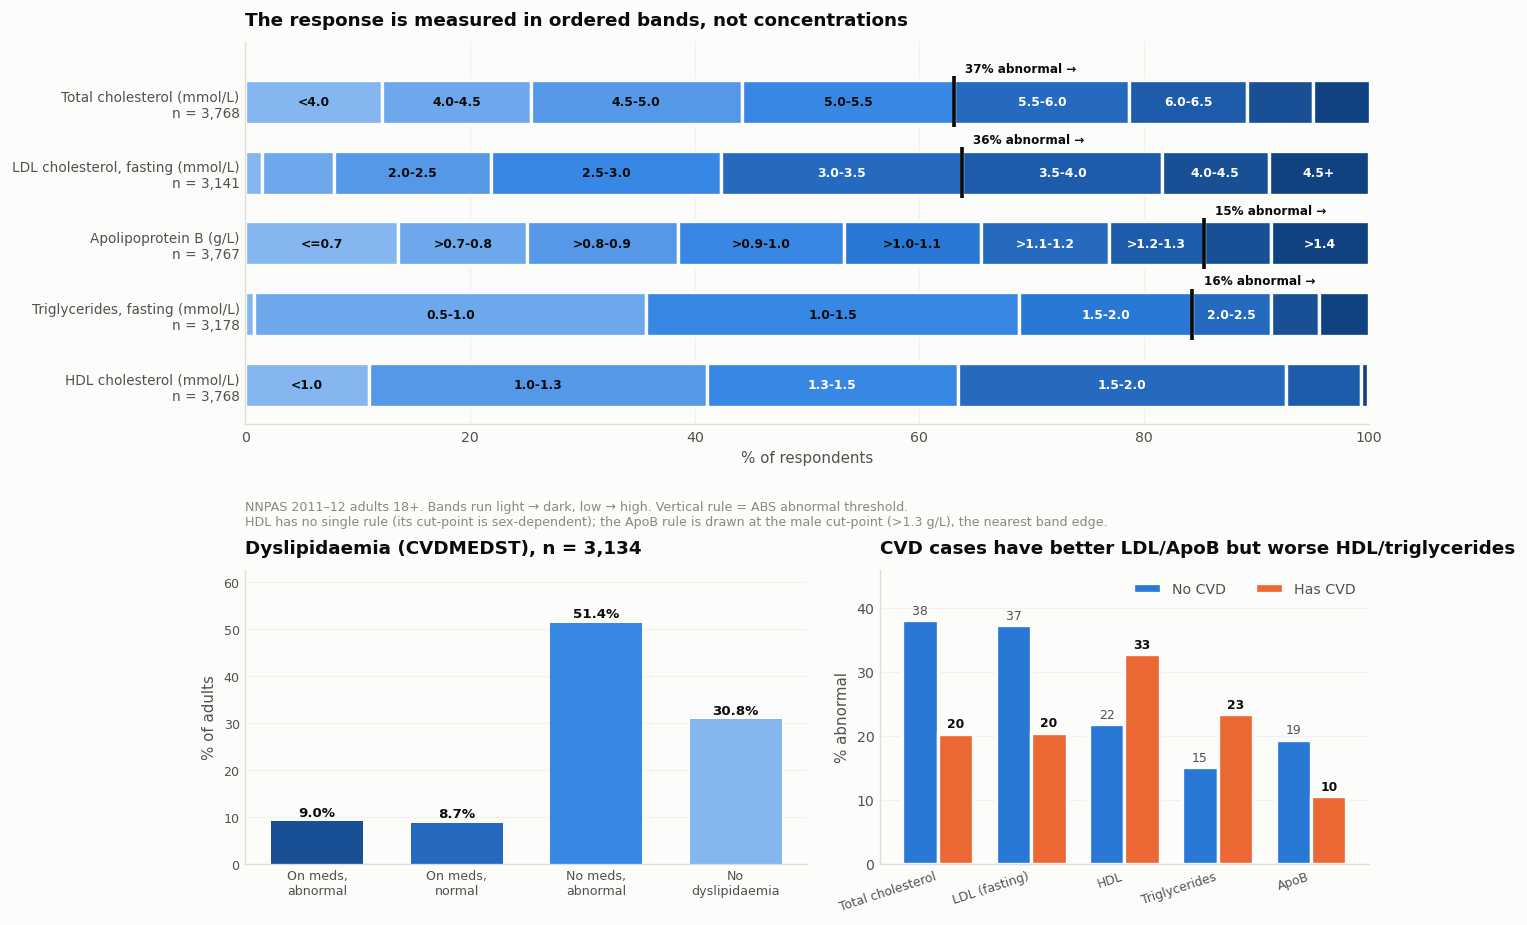

In [7]:
# ---- Figure 1: the response variable -------------------------------------
fig = plt.figure(figsize=(11.5, 7.6), constrained_layout=True)
gs  = fig.add_gridspec(2, 2, height_ratios=[1.3, 1], width_ratios=[1.15, 1])
ax1 = fig.add_subplot(gs[0, :]); ax2 = fig.add_subplot(gs[1, 0]); ax3 = fig.add_subplot(gs[1, 1])

# (a) stacked band proportions, ordinal blue ramp, abnormal boundary marked
order = ["CHOLRESB", "LDLRESB", "APOBRESB", "TRIGRESB", "HDLCHREB"]
abn_start = {"CHOLRESB": 5, "LDLRESB": 6, "APOBRESB": 8, "TRIGRESB": 5, "HDLCHREB": None}
for row, col in enumerate(order):
    tab = prop_tables[col]; colors = ordinal_ramp(len(tab))
    left = 0.0
    for i, (lab, pct) in enumerate(zip(tab.band, tab["%"])):
        ax1.barh(row, pct, left=left, height=0.62, color=colors[i],
                 edgecolor=SURFACE, linewidth=2)                    # 2px surface gap between fills
        if pct >= 7:                                                # selective direct labels only
            ax1.text(left + pct/2, row, lab, ha="center", va="center", fontsize=7.4,
                     color="#ffffff" if i >= len(tab) - 4 else INK, fontweight="600")
        left += pct
    if abn_start[col] is not None:
        x = tab["%"].iloc[:abn_start[col] - 1].sum()
        ax1.plot([x, x], [row - 0.36, row + 0.36], color=INK, lw=2.2, solid_capstyle="butt", zorder=5)
        ax1.text(x + 1.0, row - 0.38, f"{100-x:.0f}% abnormal →", fontsize=7.2, color=INK,
                 va="bottom", ha="left", fontweight="600")
ax1.set_ylim(len(order) - 0.45, -0.85)
ax1.set_yticks(range(len(order)))
ax1.set_yticklabels([f"{pretty[c]}\nn = {int(adult[c].notna().sum()):,}" for c in order], fontsize=8.2)
ax1.set_xlim(0, 100); ax1.set_xlabel("% of respondents")
ax1.set_title("The response is measured in ordered bands, not concentrations")
ax1.text(0, -0.20, "NNPAS 2011–12 adults 18+. Bands run light → dark, low → high. Vertical rule = ABS abnormal "
         "threshold.\nHDL has no single rule (its cut-point is sex-dependent); the ApoB rule is drawn at the male "
         "cut-point (>1.3 g/L), the nearest band edge.",
         transform=ax1.transAxes, fontsize=7.6, color=INK3, va="top")
ax1.grid(axis="x", alpha=0.55); ax1.set_axisbelow(True)

# (b) dyslipidaemia composite
d = adult.CVDMEDST.value_counts(normalize=True).sort_index() * 100
labs = ["On meds,\nabnormal", "On meds,\nnormal", "No meds,\nabnormal", "No\ndyslipidaemia"]
bars = ax2.bar(labs, d.values, color=[SEQ_BLUE[7], SEQ_BLUE[5], SEQ_BLUE[3], SEQ_BLUE[0]], width=0.66)
for b, v in zip(bars, d.values):
    ax2.text(b.get_x()+b.get_width()/2, v+1.2, f"{v:.1f}%", ha="center", fontsize=8,
             color=INK, fontweight="600")
ax2.set_ylim(0, max(d.values)*1.22); ax2.set_ylabel("% of adults")
ax2.set_title(f"Dyslipidaemia (CVDMEDST), n = {int(adult.CVDMEDST.notna().sum()):,}")
ax2.grid(axis="y", alpha=0.55); ax2.set_axisbelow(True); ax2.tick_params(labelsize=7.6)

# (c) abnormal % by CVD status -- two series
x = np.arange(len(by_cvd)); w = 0.38
ax3.bar(x - w/2, by_cvd["no CVD %"], w, color=CAT[0], edgecolor=SURFACE, linewidth=2, label="No CVD")
ax3.bar(x + w/2, by_cvd["CVD %"],    w, color=CAT[1], edgecolor=SURFACE, linewidth=2, label="Has CVD")
for xi, (a_, b_) in enumerate(zip(by_cvd["no CVD %"], by_cvd["CVD %"])):
    ax3.text(xi - w/2, a_ + 1.0, f"{a_:.0f}", ha="center", fontsize=7.4, color=INK2)
    ax3.text(xi + w/2, b_ + 1.0, f"{b_:.0f}", ha="center", fontsize=7.4, color=INK, fontweight="600")
ax3.set_xticks(x); ax3.set_xticklabels(by_cvd.biomarker, fontsize=7.4, rotation=18, ha="right")
ax3.set_ylabel("% abnormal"); ax3.set_ylim(0, 46)
ax3.set_title("CVD cases have better LDL/ApoB but worse HDL/triglycerides")
ax3.legend(ncol=2, loc="upper right"); ax3.grid(axis="y", alpha=0.55); ax3.set_axisbelow(True)
plt.show()

---
## 4. Predictors of interest and potential confounders

### Main predictors — diet intake

| Group | Variables |
|---|---|
| **Fat quality** | `SAT_PCT_E` (%E saturated + *trans*, 2-day mean), `TRANPER1`, `MONOPER1`, `POLYPER1`, `FATPER1` |
| **Dietary cholesterol** | `DIET_CHOL` (from `CHOLT1`/`CHOLT2`, mg) |
| **Fibre** | `FIBRE_DENS` (g/MJ), `FIBRET1`, `FIBRET2` |
| **Sodium & salt use** | `SODIUM_MG`; `DIETQ12` (salt in cooking), `DIETQ14` (salt at table) |
| **Discretionary / "ultra-processed" proxy** | `DISC_PCT`, derived from `DISCFLG` at the food level |
| **Food groups (serves/day)** | `VEGLEG1N`, `FRUIT1N`, `WHOLGR1N`, `REFGRA1N`, `MEAT1N`, `MEATL1N`, `FISH1N`, `NUTS1N`, `UNSAT1N` |
| **Dairy fat content** | `DAIRHF1N` (> 10 % fat), `DAIRMF1N` (4–10 %), `DAIRLF1N` (< 4 %) |
| **Diet-quality questions** | `DIETQ5`, `DIETQ8`, `DIETRDI` |

### Potential confounders

`AGEC` · `SEX` · `BMI` · `ENERGY_KJ` (total energy — mandatory when modelling nutrient densities) ·
**treatment status** (`LIPID_MEDS` or `HCHOLBC`) · `SMKSTAT` · `ALCPER1` · `EXLWTBC` (physical
activity) · `SF2SA1QN` (SEIFA) · `INCDEC` · `DIABBC` · `FASTSTAD`

**Treatment status is the critical confounder, and it comes with a trap.**
17.7 % of adults with a dyslipidaemia result are on lipid-lowering medication, and among CVD cases
that rises sharply. Their lipids are *treated*, and they are also the people most likely to have
changed their diet — so leaving treatment out biases diet coefficients toward the null or reverses
their sign. Figure 1c shows how large this effect is.

The trap: `CVDMEDST`, the only source of a medication indicator in NNPAS, is defined **only for
respondents who fasted**. Adjusting for `LIPID_MEDS` therefore silently re-imposes the fasting
restriction and throws away the ~590 non-fasting respondents who have a valid ApoB result — exactly
the sample-size advantage ApoB was chosen for. `HCHOLBC` (self-reported high cholesterol) is recorded
for **all 9,435 adults with no missing values** and is the better adjustment when the outcome does not
itself require fasting.

In [8]:
# ---- 5. Complete-case sample sizes ---------------------------------------
PREDICTORS = ["SAT_PCT_E", "FIBRE_DENS", "DIET_CHOL", "SODIUM_MG", "DISC_PCT",
              "DAIRHF1N", "DAIRLF1N", "VEGLEG1N", "FRUIT1N", "MEAT1N", "FISH1N", "NUTS1N"]
CONFOUND   = ["AGEC", "SEX", "BMI", "ENERGY_KJ", "SMKSTAT"]        # available for everyone

def funnel(df, steps):
    out, cur = [], df
    for label, cols in steps:
        cur = cur.dropna(subset=cols) if cols else cur
        out.append({"step": label, "n": len(cur)})
    return pd.DataFrame(out), cur

steps = [
    ("All NNPAS respondents", None),
    ("Adults 18+", None),
    ("+ 2-day dietary intake", PREDICTORS),
    ("+ age, sex, BMI, energy, smoking", CONFOUND),
    ("+ ApoB result  (no fasting needed)", ["APOBNTR"]),
    ("+ medication status (CVDMEDST: fasting only)", ["LIPID_MEDS"]),
    ("+ fasting LDL & triglycerides", ["LDLNTR", "TRIGNTR"]),
]
f_all, _ = funnel(npa, steps[:1])
f_rest, cc_fasting = funnel(adult, steps[1:])
attrition = pd.concat([f_all, f_rest], ignore_index=True)

cc_apob = adult.dropna(subset=PREDICTORS + CONFOUND + ["APOBNTR"])   # adjust treatment via HCHOLBC
cc_meds = cc_apob.dropna(subset=["LIPID_MEDS"])                      # adjust treatment via CVDMEDST

print("Complete-case attrition\n" + "="*62)
print(attrition.to_string(index=False))
print(f"\n  Diet reporting costs almost nothing : {len(adult) - attrition.n.iloc[2]:,} adults lost")
print(f"  Measured BMI costs                  : {attrition.n.iloc[2] - attrition.n.iloc[3]:,} adults")
print(f"  Blood collection costs              : {attrition.n.iloc[3] - attrition.n.iloc[4]:,} adults")
print(f"  Requiring CVDMEDST (fasting) costs  : {len(cc_apob) - len(cc_meds):,} more")
print(f"\n  >>> RECOMMENDED  ApoB + HCHOLBC adjustment    n = {len(cc_apob):,}")
print(f"      alternative  ApoB + CVDMEDST adjustment  n = {len(cc_meds):,}")
print(f"      fasting LDL / triglycerides              n = {len(cc_fasting):,}")
print(f"\n  CVD cases in the recommended sample          n = {int(cc_apob.CVD.sum()):,} "
      f"({100*cc_apob.CVD.mean():.1f} %)")
print(f"\nHCHOLBC missing values among adults: {adult.HCHOLBC.isna().sum()} "
      f"-> usable for the full non-fasting sample")

Complete-case attrition
                                        step     n
                       All NNPAS respondents 12153
                                  Adults 18+  9435
                      + 2-day dietary intake  9431
            + age, sex, BMI, energy, smoking  7956
          + ApoB result  (no fasting needed)  3584
+ medication status (CVDMEDST: fasting only)  2991
               + fasting LDL & triglycerides  2956

  Diet reporting costs almost nothing : 4 adults lost
  Measured BMI costs                  : 1,475 adults
  Blood collection costs              : 4,372 adults
  Requiring CVDMEDST (fasting) costs  : 593 more

  >>> RECOMMENDED  ApoB + HCHOLBC adjustment    n = 3,584
      alternative  ApoB + CVDMEDST adjustment  n = 2,991
      fasting LDL / triglycerides              n = 2,956

  CVD cases in the recommended sample          n = 237 (6.6 %)

HCHOLBC missing values among adults: 0 -> usable for the full non-fasting sample


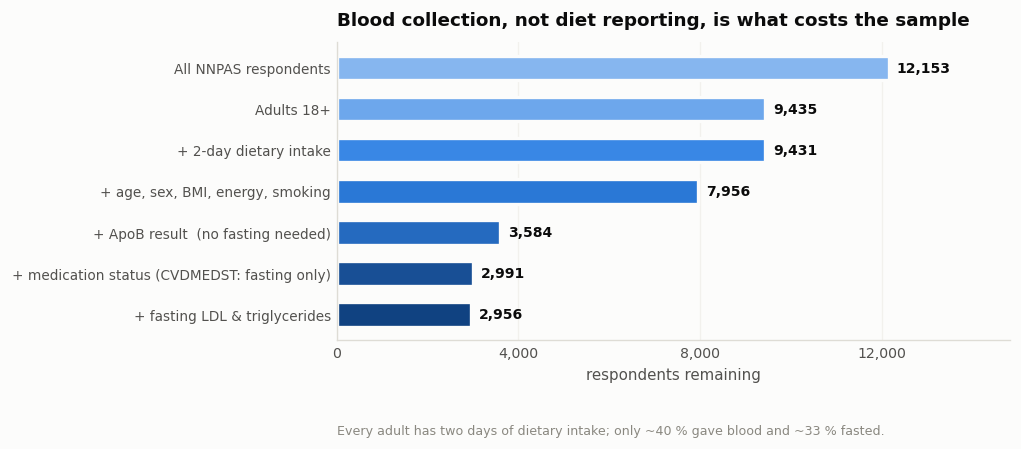

In [9]:
# ---- Figure 2: where the sample goes -------------------------------------
fig, ax = plt.subplots(figsize=(8.4, 3.6), constrained_layout=True)
total = attrition.n.iloc[0]
y = np.arange(len(attrition))
ax.barh(y, attrition.n, height=0.6, color=ordinal_ramp(len(attrition)),
        edgecolor=SURFACE, linewidth=2)
for yi, n in zip(y, attrition.n):
    ax.text(n + total*0.015, yi, f"{n:,}", va="center", fontsize=8.4, color=INK, fontweight="600")
ax.set_yticks(y); ax.set_yticklabels(attrition.step, fontsize=8.2)
ax.invert_yaxis(); ax.set_xlim(0, total*1.22); ax.set_xlabel("respondents remaining")
ax.set_title("Blood collection, not diet reporting, is what costs the sample")
ax.grid(axis="x", alpha=0.55); ax.set_axisbelow(True)
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.text(0, -0.28, "Every adult has two days of dietary intake; only ~40 % gave blood and ~33 % fasted.",
        transform=ax.transAxes, fontsize=7.6, color=INK3, va="top")
plt.show()

---
## 6. Simple analyses — does diet move the lipid profile?

Three passes, in increasing strength:

1. **Spearman rank correlations** between each diet variable and each banded biomarker — appropriate
   for an ordered categorical outcome, with no distributional assumption.
2. **Abnormal-lipid prevalence across intake quintiles** for the nutrients with the strongest prior
   (saturated fat, fibre, discretionary energy) — shows whether a dose–response gradient is visible.
3. **Multivariable logistic regression** for abnormal ApoB, adjusted for the confounders above,
   fitted twice — once with each treatment-adjustment strategy — to show what the fasting restriction
   costs.

In [10]:
# ---- Pass 1: Spearman rank correlations ---------------------------------
DIET_VARS = {"SAT_PCT_E":"Saturated + trans fat (%E)", "FIBRE_DENS":"Fibre density (g/MJ)",
             "DIET_CHOL":"Dietary cholesterol (mg)", "SODIUM_MG":"Sodium (mg)",
             "DISC_PCT":"Discretionary energy (%)", "DAIRHF1N":"Higher-fat dairy (serves)",
             "DAIRLF1N":"Lower-fat dairy (serves)", "MEAT1N":"Meat & alternatives (serves)",
             "FISH1N":"Fish & seafood (serves)", "NUTS1N":"Nuts & seeds (serves)",
             "VEGLEG1N":"Vegetables & legumes (serves)", "FRUIT1N":"Fruit (serves)"}
BIO_VARS = ["CHOLRESB", "LDLRESB", "APOBRESB", "TRIGRESB", "HDLCHREB"]

rho  = pd.DataFrame(index=list(DIET_VARS), columns=BIO_VARS, dtype=float)
pval = rho.copy()
for d in DIET_VARS:
    for b in BIO_VARS:
        s = adult[[d, b]].dropna()
        rho.loc[d, b], pval.loc[d, b] = stats.spearmanr(s[d], s[b])

disp = rho.round(3).astype(str) + np.where(pval < 0.01, "**", np.where(pval < 0.05, "*", ""))
disp.index   = [DIET_VARS[i] for i in rho.index]
disp.columns = [pretty[c].split(" (")[0] for c in BIO_VARS]
print("Spearman rho, diet vs lipid band  (NNPAS adults 18+;  * p<0.05, ** p<0.01)\n" + "="*95)
print(disp.to_string())

flat = (rho.stack().rename("rho").to_frame().join(pval.stack().rename("p").to_frame())
        .assign(abs_rho=lambda t: t.rho.abs()).sort_values("abs_rho", ascending=False).head(8))
flat.index = [f"{DIET_VARS[a]}  x  {pretty[b].split(' (')[0]}" for a, b in flat.index]
print("\nStrongest associations:")
print(flat[["rho", "p"]].round(4).to_string())
print(f"\nLargest |rho| anywhere in the matrix: {rho.abs().values.max():.3f} "
      f"-> at most {100*rho.abs().values.max()**2:.1f} % of shared variance.")

Spearman rho, diet vs lipid band  (NNPAS adults 18+;  * p<0.05, ** p<0.01)
                              Total cholesterol LDL cholesterol, fasting Apolipoprotein B Triglycerides, fasting HDL cholesterol
Saturated + trans fat (%E)               -0.002                    0.021          0.053**                 -0.002          -0.025
Fibre density (g/MJ)                    -0.041*                  -0.045*         -0.077**               -0.057**         0.071**
Dietary cholesterol (mg)                  0.003                   0.041*           0.06**                  0.002        -0.049**
Sodium (mg)                            -0.048**                    -0.02           0.038*                  0.002        -0.088**
Discretionary energy (%)                  0.008                     0.01            0.021                 0.041*          -0.013
Higher-fat dairy (serves)                -0.017                   -0.021           -0.031                 -0.033           0.023
Lower-fat dairy (serve

In [11]:
# ---- Pass 2: dose-response across intake quintiles -----------------------
def quintile_profile(df, var, flag, k=5):
    s = df[[var, flag]].dropna().copy()
    s["q"] = pd.qcut(s[var], k, labels=[f"Q{i}" for i in range(1, k+1)])
    g = s.groupby("q", observed=True)[flag].agg(["mean", "size"])
    g["pct"] = 100*g["mean"]
    g["se"]  = 100*np.sqrt(g["mean"]*(1-g["mean"])/g["size"])
    g["range"] = s.groupby("q", observed=True)[var].agg(lambda v: f"{v.min():.1f}-{v.max():.1f}").values
    return g

profiles = {}
for var in ["SAT_PCT_E", "FIBRE_DENS", "DISC_PCT"]:
    for flag in ["APOBNTR_ABN", "LDLNTR_ABN"]:
        profiles[(var, flag)] = quintile_profile(adult, var, flag)

for var in ["SAT_PCT_E", "FIBRE_DENS", "DISC_PCT"]:
    print(f"\n% with abnormal ApoB by quintile of {DIET_VARS[var]}")
    print(profiles[(var, "APOBNTR_ABN")][["range", "size", "pct"]].round(1).to_string())

print("\n\nTrend test (Spearman on individual data, abnormal flag vs continuous intake)")
for (var, flag), _ in profiles.items():
    s = adult[[var, flag]].dropna()
    r, p = stats.spearmanr(s[var], s[flag])
    print(f"  {flag.replace('NTR_ABN',''):>5} ~ {DIET_VARS[var]:<32} rho = {r:+.4f}   p = {p:.4f}")


% with abnormal ApoB by quintile of Saturated + trans fat (%E)
        range  size   pct
q                        
Q1    0.2-6.8   754  16.3
Q2    6.8-9.5   754  17.9
Q3   9.5-11.9   754  18.6
Q4  11.9-14.5   751  21.6
Q5  14.5-29.5   754  19.8

% with abnormal ApoB by quintile of Fibre density (g/MJ)
       range  size   pct
q                       
Q1   0.0-2.0   754  21.6
Q2   2.0-2.5   753  18.9
Q3   2.5-3.0   753  16.7
Q4   3.0-3.7   753  19.1
Q5  3.7-12.9   754  17.8

% with abnormal ApoB by quintile of Discretionary energy (%)
        range  size   pct
q                        
Q1   0.0-14.5   754  19.1
Q2  14.5-25.6   753  18.3
Q3  25.6-36.9   753  17.8
Q4  36.9-50.4   753  18.9
Q5  50.5-99.9   753  20.1


Trend test (Spearman on individual data, abnormal flag vs continuous intake)
   APOB ~ Saturated + trans fat (%E)       rho = +0.0357   p = 0.0286
    LDL ~ Saturated + trans fat (%E)       rho = +0.0202   p = 0.2580
   APOB ~ Fibre density (g/MJ)             rho = -0.0314  

In [12]:
# ---- Pass 3: adjusted logistic regression -------------------------------
def logit_fit(X, y, max_iter=200, tol=1e-10):
    """Unpenalised binary logistic regression by Newton-Raphson (no statsmodels dependency)."""
    X, y = np.asarray(X, float), np.asarray(y, float)
    b = np.zeros(X.shape[1])
    for _ in range(max_iter):
        p = 1/(1 + np.exp(-(X @ b)))
        W = np.clip(p*(1-p), 1e-10, None)
        step = np.linalg.solve((X*W[:, None]).T @ X, X.T @ (y - p))
        b += step
        if np.max(np.abs(step)) < tol:
            break
    p = 1/(1 + np.exp(-(X @ b)))
    ll = np.sum(y*np.log(np.clip(p, 1e-12, 1)) + (1-y)*np.log(np.clip(1-p, 1e-12, 1)))
    cov = np.linalg.inv((X*np.clip(p*(1-p), 1e-10, None)[:, None]).T @ X)
    return dict(beta=b, se=np.sqrt(np.diag(cov)), ll=ll, n=len(y))

def logit_table(df, outcome, terms):
    d = df[[outcome] + terms].dropna()
    X = np.column_stack([np.ones(len(d))] + [d[t].astype(float).values for t in terms])
    f = logit_fit(X, d[outcome].astype(float).values)
    z = f["beta"]/f["se"]
    out = pd.DataFrame({"term": ["(intercept)"] + terms, "beta": f["beta"], "se": f["se"],
                        "OR": np.exp(f["beta"]), "z": z, "p": 2*stats.norm.sf(np.abs(z))})
    out["CI low"], out["CI high"] = np.exp(f["beta"] - 1.96*f["se"]), np.exp(f["beta"] + 1.96*f["se"])
    return out, f, len(d)

model_df = adult.assign(
    FEMALE    = (adult.SEX == 2).astype(float),
    AGE_10    = adult.AGEC/10,
    ENERGY_MJ = adult.ENERGY_KJ/1000,
    SMOKER    = adult.SMKSTAT.isin([1, 2, 3]).astype(float),
    APOB_ABN  = adult.APOBNTR_ABN.astype(float),
    HICHOL    = adult.HCHOLBC.isin([1, 2, 3]).astype(float))   # self-reported high cholesterol

DIET_TERMS = ["SAT_PCT_E", "FIBRE_DENS", "DISC_PCT"]
BASE_CONF  = ["AGE_10", "FEMALE", "BMI", "ENERGY_MJ", "SMOKER"]

# Model A - recommended: treatment proxied by self-reported high cholesterol (no fasting needed)
tab_adj, _, n_adj = logit_table(model_df, "APOB_ABN", DIET_TERMS + BASE_CONF + ["HICHOL", "CVD"])
print(f"MODEL A  abnormal ApoB ~ diet + confounders + high cholesterol + CVD"
      f"      n = {n_adj:,}\n" + "="*88)
print(tab_adj.round(4).to_string(index=False))

# Model B - same, but treatment taken from CVDMEDST, which forces the fasting restriction
tab_meds, _, n_meds = logit_table(model_df, "APOB_ABN", DIET_TERMS + BASE_CONF + ["LIPID_MEDS", "CVD"])
print(f"\nMODEL B  same, but adjusted with the CVDMEDST-derived medication flag"
      f"       n = {n_meds:,}   ({n_adj - n_meds} respondents lost)\n" + "="*88)
print(tab_meds.round(4).to_string(index=False))

# Unadjusted, for comparison
tab_crude, _, n_crude = logit_table(model_df, "APOB_ABN", DIET_TERMS)
print(f"\nUNADJUSTED  the same three diet terms only"
      f"                                 n = {n_crude:,}\n" + "="*88)
print(tab_crude.round(4).to_string(index=False))

print("\nDiet terms: none reach p < 0.05 in either adjusted model.")
print("Treatment adjustment is strong and protective-looking (OR < 1) because those respondents'")
print("lipids are already treated - which is exactly why it must not be omitted.")

MODEL A  abnormal ApoB ~ diet + confounders + high cholesterol + CVD      n = 3,584
       term    beta     se     OR       z      p  CI low  CI high
(intercept) -3.4626 0.3569 0.0313 -9.7026 0.0000  0.0156   0.0631
  SAT_PCT_E  0.0112 0.0115 1.0112  0.9711 0.3315  0.9887   1.0342
 FIBRE_DENS -0.0760 0.0458 0.9268 -1.6594 0.0970  0.8472   1.0139
   DISC_PCT -0.0023 0.0024 0.9977 -0.9359 0.3493  0.9930   1.0025
     AGE_10  0.1148 0.0297 1.1216  3.8712 0.0001  1.0583   1.1888
     FEMALE  0.0879 0.0934 1.0918  0.9411 0.3466  0.9093   1.3111
        BMI  0.0459 0.0077 1.0470  6.0014 0.0000  1.0314   1.0628
  ENERGY_MJ  0.0176 0.0163 1.0178  1.0834 0.2786  0.9858   1.0508
     SMOKER  0.5272 0.1193 1.6943  4.4193 0.0000  1.3410   2.1406
     HICHOL  0.3032 0.1125 1.3541  2.6944 0.0071  1.0861   1.6883
        CVD -1.0841 0.2244 0.3382 -4.8303 0.0000  0.2178   0.5251

MODEL B  same, but adjusted with the CVDMEDST-derived medication flag       n = 2,991   (593 respondents lost)
       term 

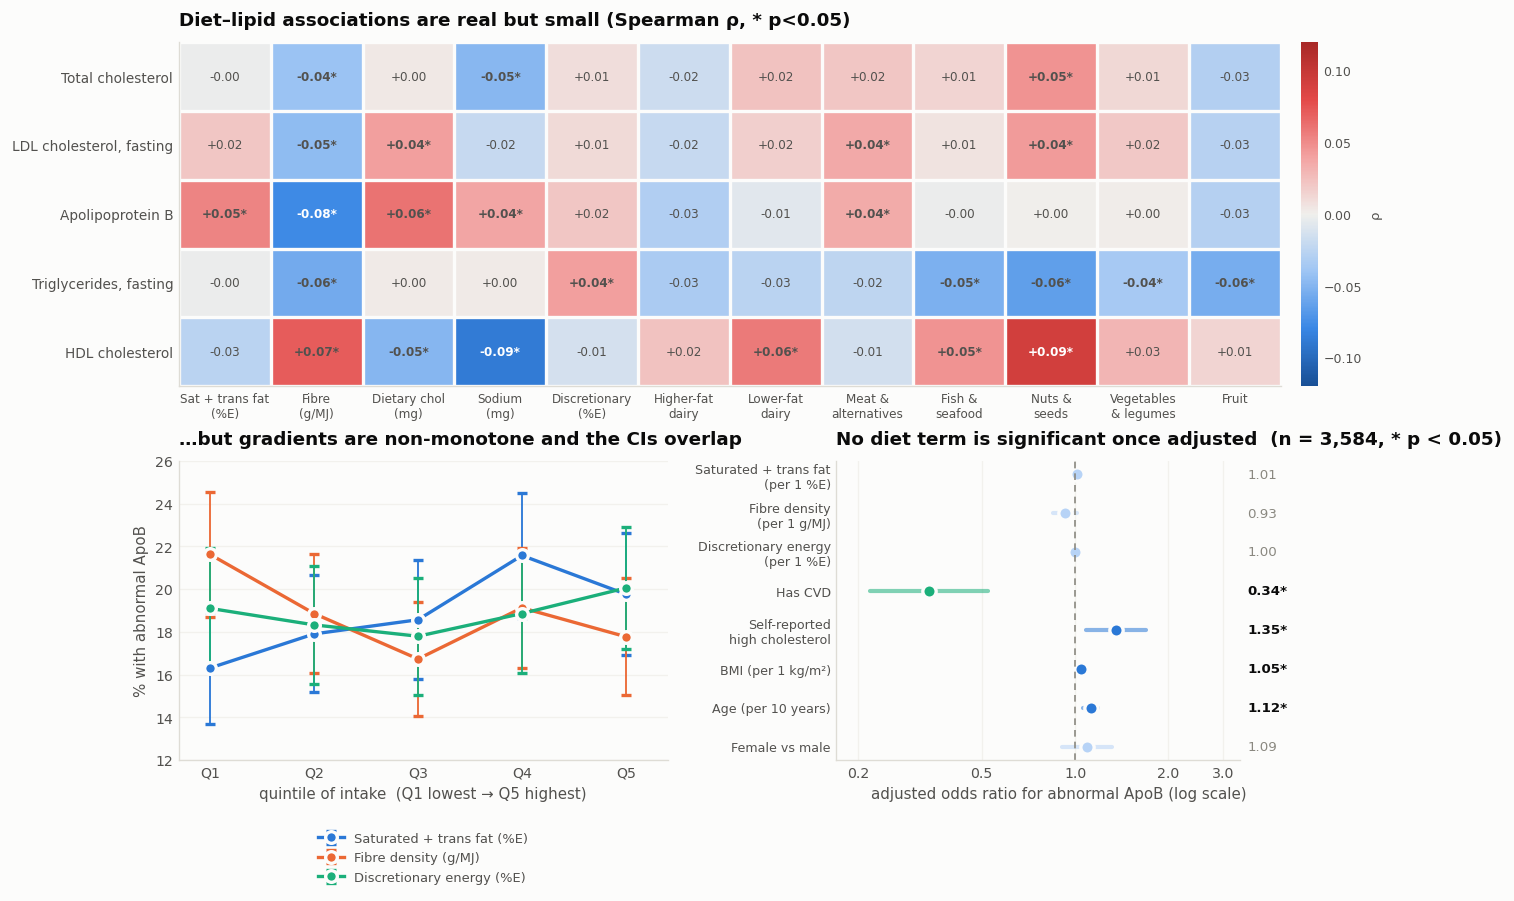

In [13]:
# ---- Figure 3: initial results -------------------------------------------
fig = plt.figure(figsize=(11.5, 7.4), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1], width_ratios=[1.1, 1])
axA = fig.add_subplot(gs[0, :]); axB = fig.add_subplot(gs[1, 0]); axC = fig.add_subplot(gs[1, 1])

# (A) diverging correlation heatmap
SHORT = {"SAT_PCT_E":"Sat + trans fat\n(%E)", "FIBRE_DENS":"Fibre\n(g/MJ)", "DIET_CHOL":"Dietary chol\n(mg)",
         "SODIUM_MG":"Sodium\n(mg)", "DISC_PCT":"Discretionary\n(%E)", "DAIRHF1N":"Higher-fat\ndairy",
         "DAIRLF1N":"Lower-fat\ndairy", "MEAT1N":"Meat &\nalternatives", "FISH1N":"Fish &\nseafood",
         "NUTS1N":"Nuts &\nseeds", "VEGLEG1N":"Vegetables\n& legumes", "FRUIT1N":"Fruit"}
mat = rho.values.astype(float)
im = axA.imshow(mat.T, cmap=DIVERGING, vmin=-0.12, vmax=0.12, aspect="auto")
axA.set_xticks(range(len(rho.index)))
axA.set_xticklabels([SHORT[i] for i in rho.index], fontsize=7.2)
axA.set_yticks(range(len(BIO_VARS)))
axA.set_yticklabels([pretty[c].split(" (")[0] for c in BIO_VARS], fontsize=8.2)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        r, p = mat[i, j], pval.values[i, j]
        axA.text(i, j, f"{r:+.02f}" + ("*" if p < 0.05 else ""), ha="center", va="center",
                 fontsize=7.2, fontweight="600" if p < 0.05 else "400",
                 color="#ffffff" if abs(r) > 0.075 else INK2)
axA.set_xticks(np.arange(-.5, len(rho.index), 1), minor=True)
axA.set_yticks(np.arange(-.5, len(BIO_VARS), 1), minor=True)
axA.grid(which="minor", color=SURFACE, linewidth=2); axA.tick_params(which="minor", length=0)
axA.set_title("Diet–lipid associations are real but small (Spearman ρ, * p<0.05)")
cb = fig.colorbar(im, ax=axA, fraction=0.022, pad=0.012); cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=7.5, color=INK3); cb.set_label("ρ", fontsize=8, color=INK2)

# (B) dose-response, three series
for i, (var, lab) in enumerate([("SAT_PCT_E", "Saturated + trans fat (%E)"),
                                ("FIBRE_DENS", "Fibre density (g/MJ)"),
                                ("DISC_PCT", "Discretionary energy (%E)")]):
    g = profiles[(var, "APOBNTR_ABN")]
    axB.errorbar(np.arange(1, 6), g.pct, yerr=1.96*g.se, color=CAT[i], lw=2, marker="o", ms=7,
                 capsize=3, elinewidth=1.1, markeredgecolor=SURFACE, markeredgewidth=2, label=lab)
axB.set_xticks(range(1, 6)); axB.set_xticklabels([f"Q{i}" for i in range(1, 6)])
axB.set_xlabel("quintile of intake  (Q1 lowest → Q5 highest)")
axB.set_ylabel("% with abnormal ApoB")
axB.set_title("…but gradients are non-monotone and the CIs overlap")
axB.legend(loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=1, fontsize=7.8)
axB.grid(axis="y", alpha=0.55); axB.set_axisbelow(True)
axB.set_xlim(0.7, 5.4); axB.set_ylim(12, 26)

# (C) adjusted odds ratios, single series
plot_terms = ["SAT_PCT_E", "FIBRE_DENS", "DISC_PCT", "CVD", "HICHOL", "BMI", "AGE_10", "FEMALE"]
nice = {"SAT_PCT_E": "Saturated + trans fat\n(per 1 %E)", "FIBRE_DENS": "Fibre density\n(per 1 g/MJ)",
        "DISC_PCT": "Discretionary energy\n(per 1 %E)", "CVD": "Has CVD",
        "HICHOL": "Self-reported\nhigh cholesterol", "BMI": "BMI (per 1 kg/m²)",
        "AGE_10": "Age (per 10 years)", "FEMALE": "Female vs male"}
sub = tab_adj.set_index("term").loc[plot_terms]
y = np.arange(len(sub))[::-1]
XMIN, XTEXT = 0.17, 3.6
for yi, (name, r) in zip(y, sub.iterrows()):
    sig = r.p < 0.05
    c = (CAT[0] if r.OR >= 1 else CAT[2]) if sig else "#b7d3f6"     # non-significant terms recede
    axC.plot([r["CI low"], r["CI high"]], [yi, yi], color=c, lw=2.5, solid_capstyle="round", alpha=0.55)
    axC.plot(r.OR, yi, "o", color=c, ms=8, markeredgecolor=SURFACE, markeredgewidth=2)
    axC.text(XTEXT, yi, f"{r.OR:.2f}" + ("*" if sig else ""), fontsize=8, va="center",
             ha="left", color=INK if sig else INK3, fontweight="600" if sig else "400")
axC.axvline(1, color=INK3, lw=1, ls=(0, (4, 3)))
axC.set_yticks(y); axC.set_yticklabels([nice[t] for t in sub.index], fontsize=7.6)
axC.set_xscale("log"); axC.set_xlim(XMIN, 4.6)
axC.set_xticks([0.2, 0.5, 1, 2, 3]); axC.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
axC.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
axC.xaxis.set_minor_locator(mpl.ticker.NullLocator())
axC.set_xlabel("adjusted odds ratio for abnormal ApoB (log scale)")
axC.set_title(f"No diet term is significant once adjusted  (n = {n_adj:,}, * p < 0.05)")
axC.grid(axis="x", alpha=0.55); axC.set_axisbelow(True)
axC.spines["bottom"].set_bounds(XMIN, 3.4)
plt.show()

---
## Verdict

**Can the research question be answered with this data? Yes — every variable exists and the sample is
adequate. But the diet signal is weak, and it is better to know that now than after the analysis is
written.**

1. **Bivariate associations are statistically significant but tiny.** Every diet–lipid Spearman ρ
   sits between −0.09 and +0.09 — the largest are nuts & seeds ↔ HDL (ρ = +0.09), sodium ↔ HDL
   (ρ = −0.09) and fibre density ↔ ApoB (ρ = −0.08). All are correctly signed, and none explains more
   than about 1 % of the variance.
2. **Nothing survives adjustment.** In Model A no diet term reaches p < 0.05; fibre density comes
   closest (OR = 0.93, p = 0.097). What *is* significant is age, BMI, smoking, self-reported high
   cholesterol and CVD status. The quintile gradients in Figure 3B are non-monotone with overlapping
   confidence intervals.
3. **The outcome is banded, not continuous.** Model it as ordinal or as a binary abnormal flag.
   Band midpoints are fine for description; a linear regression on them is not.
4. **Sample size is set by blood collection, not by diet.** All 9,435 adults have two days of intake:
   diet reporting costs only 4 respondents, measured BMI costs ~1,475, and blood collection costs
   ~4,372 more.

The most likely explanation is measurement error, not absent biology. Two days of 24-hour recall are
a poor estimate of the habitual intake that shaped a person's lipids over years, and that attenuates
correlations sharply. The question remains answerable — but frame it as *"how much of the variation in
lipid profile can short-term self-reported diet explain?"*, with a genuinely small answer, rather than
promising a strong diet effect.

### The "of CVD" part of the question needs care

Adults with CVD have a **better** measured LDL, total cholesterol and ApoB than adults without it, but
a **worse** HDL and triglycerides (Figure 1c). Abnormal total cholesterol runs 38 % without CVD versus
20 % with it; abnormal ApoB, 19 % versus 10 %.

That is not evidence that CVD improves cholesterol. **62.9 % of CVD cases are on lipid-lowering
medication, against 14.5 % of everyone else** — it is the signature of statin treatment, which lowers
apoB-carrying particles and does comparatively little for HDL and triglycerides. Any comparison of
lipid profiles by CVD status must adjust for treatment or it will report a backwards result. In
Model A, `CVD` carries OR = 0.34 for abnormal ApoB, which is a treatment effect wearing a disease label.

This also means **CVD status is a collider-like variable here**: it is downstream of past lipid levels
and upstream of current treatment. Treat it as a stratifier or an adjusted covariate, and do not read
its coefficient causally.

### Recommended primary specification

Use **abnormal ApoB** (`APOBNTR`) as the primary response, not fasting LDL:

- it does not require fasting, so more respondents qualify (**3,584** vs 2,956);
- it is the mechanistically correct variable for the group's stated argument — cholesterol enters the
  arterial wall only within apoB particles, so particle number is what matters;
- `LDLRESB`, `CHOLRESB` and `CVDMEDST` then serve as sensitivity analyses.

**Adjust for treatment with `HCHOLBC`, not `LIPID_MEDS`.** `CVDMEDST` exists only for respondents who
fasted, so adjusting with it re-imposes the fasting restriction and drops the sample from
**3,584 to 2,991** — surrendering the whole reason ApoB was chosen. `HCHOLBC` is complete for all
9,435 adults.

### What cannot be done

- **No VLDL**, as expected. Estimate it as `TG / 2.2` from fasting triglyceride midpoints, or drop it.
- **No NOVA / ultra-processed classification.** `DISC_PCT` (discretionary energy share, median ≈ 31 %)
  is the closest proxy and should be named as such.
- **No milk-type variable.** `DIETQ1` and `MILKFATU` are NHS-only, and NHS respondents are a separate
  sample. Use `DAIRHF1N` / `DAIRMF1N` / `DAIRLF1N` instead.
- **Cross-sectional only.** Diet is measured after the lipid-relevant exposure period, so every result
  is an association, never an effect.